# Linear Regression on Taiwanese House Price with RandomForest

## Backgroud

![](https://img.capital.com/imgs/articles/800x600x1/shutterstock_1866666415_0.jpg)

As part of the younger generation in Taiwan, it is common to plan for purchasing a house as they establish their own families. Understanding how real-world factors influence house prices can help this generation better predict costs and prepare early for their future financial planning.

The dataset includes **414** rows of real-world housing price data from Taiwan, with the following columns:

1. **dist_to_mrt_m**: Distance to the nearest MRT (Mass Rapid Transit) station in meters.
2. **n_convenience**: Number of convenience stores within a certain radius of the house.
3. **house_age_years**: Age of the house in years, categorized into ranges (e.g., 0 to 15 years).
4. **price_twd_msq**: House price per square meter in New Taiwan Dollars (TWD).


## Goals

1. Develop a model capable of predicting house prices using the available features, such as distance to the nearest MRT station and the number of convenience stores.
2. Be able to asses the performance of our model and explore opportunities for improvement through feature engineering.
2. Implement ensemble methods to further enhance the model's performance.


## Import Data

In [8]:
# Import seaborn with alias sns
import pandas as pd
import seaborn as sns

# Import matplotlib.pyplot with alias plt
import matplotlib.pyplot as plt

In [9]:
taiwan_real_estate=pd.read_csv("/Users/sungjen_yen/Downloads/taiwan_real_estate2.csv")
taiwan_real_estate.head()

,dist_to_mrt_m,n_convenience,house_age_years,price_twd_msq
0,84.87882,10,30 to 45,11.467474
1,306.59470,9,15 to 30,12.768533
2,561.98450,5,0 to 15,14.311649
3,561.98450,5,0 to 15,16.580938
4,390.56840,5,0 to 15,13.040847


## EDA

### Exploring numeric variables

Assume we want to know how the number of convenience stores affects the price per square meter in Taiwan. For numerical variables, we can use a scatterplot to explore the trend of the interaction.

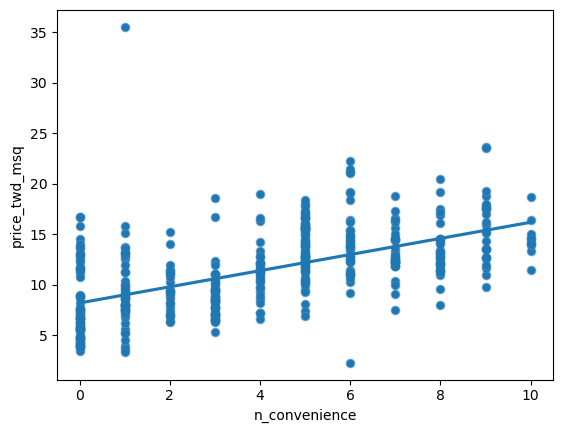

In [13]:
# Draw the scatter plot
sns.scatterplot(x='n_convenience', 
                y='price_twd_msq',
                data=taiwan_real_estate)

# Draw a trend line on the scatter plot of price_twd_msq vs. n_convenience
sns.regplot(x="n_convenience",
            y="price_twd_msq",
            data=taiwan_real_estate,
            ci=None,
            scatter_kws={'alpha': 0.5})

# Show the plot
plt.show()

It looks like **as the number of convenience stores increases, the price per square meter increases as well**. This information helps us understand that there is a positive linear relationship between the number of convenience stores and the price per square meter, which will be a useful feature for our later model.

### Exploring categorical variables

The Taiwan real estate dataset has a categorical variable in the form of the age of each house. The ages have been split into 3 groups: 0 to 15 years, 15 to 30 years, and 30 to 45 years.

Since this explanatory variable is categorical, the scatter plot that we used before to visualize the data may not make sense. Instead, a good option is to draw a histogram for each category.

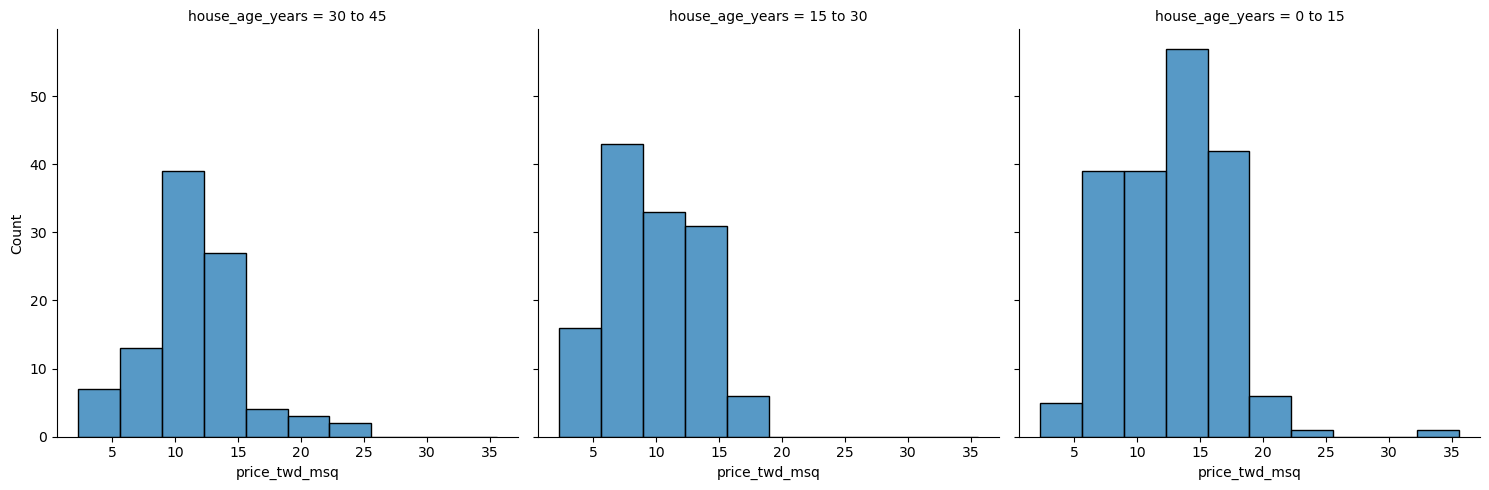

In [17]:
# Histograms of price_twd_msq with 10 bins, split by the age of each house
sns.displot(data=taiwan_real_estate,
            x='price_twd_msq',
            col='house_age_years',
            bins=10)

# Show the plot
plt.show()

It appears that new houses are the most expensive on average, and the medium aged ones (15 to 30 years) are the cheapest. To verify, we can also calculate the summary statisitc using groupby method.

In [19]:
taiwan_real_estate.groupby('house_age_years')['price_twd_msq'].mean()

house_age_years
0 to 15     12.637471
15 to 30     9.876743
30 to 45    11.393264
Name: price_twd_msq, dtype: float64

By exploring the categorical variables `house_age_years`, we can summarize the following information:

1. **Encoding Strategy**: Snce now we know that `house_age_years` is influential,  we can decide how to encode this categorical variable. Most often methods are one-hot encoding, label encoding, or even target encoding, depending on the model we choose to use.

2. **Model Interpretability**: Understanding how housing age impacts price enhances the interpretability of our model. It helps us explain why a particular house is predicted to have a higher or lower price, based on its age category.

## Linear Regression With One Variable (number of convenience stores)

The most useful feature of statistical models like linear regression is that they allow us to make predictions. 

Let's create a single linear model `mdl_price_vs_conv` and try feeding it a generated number of convenience stores and see if the predictions for the corresponding response variable (which is price per square meter) make sense.

In [23]:
# Import the ols function
from statsmodels.formula.api import ols

# Create the model object
mdl_price_vs_conv = ols("price_twd_msq ~ n_convenience", data=taiwan_real_estate)

# Fit the model
mdl_price_vs_conv = mdl_price_vs_conv.fit()

# Print the parameters of the fitted model
print(mdl_price_vs_conv.params)

Intercept        8.224237
n_convenience    0.798080
dtype: float64


From the statsmodels, we can see:
1. On average, a house with zero convenience stores nearby had a price of 8.2242 TWD per square meter.
2. If we increase the number of nearby convenience stores by one, then the expected increase in house price is 0.7981 TWD per square meter.

Now we will create a DataFrame of predictions named prediction_data. Start with explanatory_data, then add an extra column, price_twd_msq, containing the predictions we created in the previous step.

In [26]:
# Import numpy with alias np
import numpy as np

# Create explanatory_data, assuming the number of convenience stores range from 0-10 
explanatory_data = pd.DataFrame({'n_convenience': np.arange(0, 11)})

# Use mdl_price_vs_conv to predict with explanatory_data, call it price_twd_msq
price_twd_msq = mdl_price_vs_conv.predict(explanatory_data)

# Create prediction_data
prediction_data = explanatory_data.assign(price_twd_msq=price_twd_msq)

# Print the result
print(prediction_data)

    n_convenience  price_twd_msq
0               0       8.224237
1               1       9.022317
2               2       9.820397
3               3      10.618477
4               4      11.416556
5               5      12.214636
6               6      13.012716
7               7      13.810795
8               8      14.608875
9               9      15.406955
10             10      16.205035


### Check Extrapolating

To assess the validity of our predictions, let's plot the predicted values onto the original dataset's scatter plot. By comparing both on the same plot, we can visually examine how well the predicted values align with the actual data, helping us understand the relationship between the variables and the accuracy of the prediction model. 

To differentiate between the original dataset and the predictions, we will use red dots to represent the predicted values.

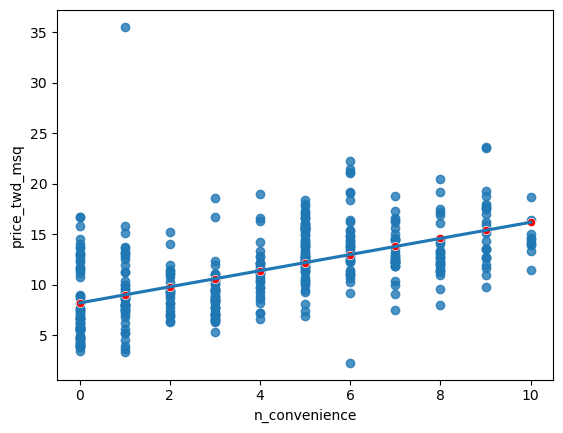

In [29]:
# Create a new figure, fig
fig = plt.figure()

sns.regplot(x="n_convenience",
            y="price_twd_msq",
            data=taiwan_real_estate,
            ci=None)

# Add a scatter plot layer to the regplot
sns.scatterplot(x="n_convenience",
                y="price_twd_msq",
                data=prediction_data,
                color="red")

# Show the layered plot
plt.show()

Naturally, the predicted values should align with the trend line of the original data!

However, to fully evaluate the model, we also need to test predictions for data points that lie beyond the range of the original dataset. This helps us assess whether the model might produce misleading results and determine if it's reasonable to use the model for extrapolation.

In [31]:
# Define a DataFrame impossible
impossible = pd.DataFrame({"n_convenience": [-1, 2.5]})

# Use mdl_price_vs_conv to predict with impossible data, call it price_twd_msq2
price_twd_msq2 = mdl_price_vs_conv.predict(impossible)

# Create prediction_data2
prediction_data2 = impossible.assign(price_twd_msq=price_twd_msq2)

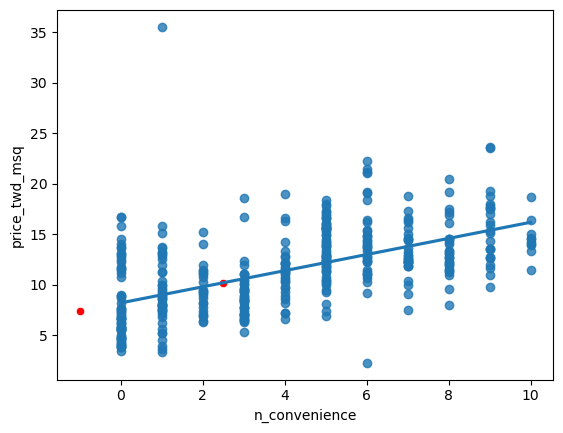

In [32]:
# Create a new figure, fig
fig = plt.figure()

sns.regplot(x="n_convenience",
            y="price_twd_msq",
            data=taiwan_real_estate,
            ci=None)

# Add a scatter plot layer to the regplot
sns.scatterplot(x="n_convenience",
                y="price_twd_msq",
                data=prediction_data2,
                color="red")

# Show the layered plot
plt.show()

The model successfully gives a prediction about cases that are impossible in real life. 

Alhtough the model can give us predictions that don't make any sense when applied to our data. We need to understand what your data means in order to determine whether a prediction is nonsense or not.

### Assess Model Fit

Besides plotting the predictions on the original dataset, we would need a more quantitative approach to assess how well our model performs. One useful feature provided by statsmodels is the model.summary() function, which offers a detailed statistical summary of the model’s performance.

#### R-squared

In [37]:
print(mdl_price_vs_conv.summary())

                            OLS Regression Results                            
Dep. Variable:          price_twd_msq   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     199.3
Date:                Sat, 07 Sep 2024   Prob (F-statistic):           3.41e-37
Time:                        20:04:21   Log-Likelihood:                -1091.1
No. Observations:                 414   AIC:                             2186.
Df Residuals:                     412   BIC:                             2194.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         8.2242      0.285     28.857

From the model, we can summarize:

1. The R-squared value is 0.326. This means that **approximately 32.6% of the variance** in the dependent variable (price_twd_msq) is explained by the independent variable (n_convenience).
2. The coefficient for n_convenience is 0.7981. This suggests that **for each additional convenience store, the price per square meter increases by 0.7981 units**, holding all else constant. This is statistically significant with a p-value of 0.000.

**Possible model enhancements:**

1. **Transform Variables**:

   Given the non-normal distribution of residuals, we might consider **transforming the dependent variable (price_twd_msq)**. For instance, applying a log transformation could help stabilize variance and normalize the distribution.

2. **Include Additional Predictors**:

   The relatively low R-squared value suggests that other factors might be influencing the dependent variable. **Incorporating additional variables, such as distance to the MRT station, property age might improve the model's explanatory power.** Also, we can consider **interaction terms** or polynomial terms that can help explain the non-linear relationships between predictors and the target variable.

## Feature Engneering

### Transforming Varaibles

From our previous observation, it seems that there are some non-linear residuals that may not be explained by using only one variable. This time, we will try including `dist_to_mrt_m` as another variable to see how our model performs.

Before we include `dist_to_mrt_m`, we should check whether this independent variable has a linear relationship with the dependent variable to avoid potential issues that may require a polynomial transformation.

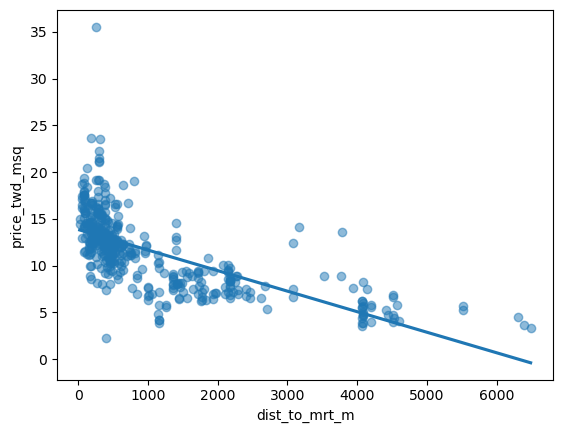

In [43]:
# Draw a trend line on the scatter plot of price_twd_msq vs. n_convenience
sns.regplot(x="dist_to_mrt_m",
            y="price_twd_msq",
            data=taiwan_real_estate,
            ci=None,
            scatter_kws={'alpha': 0.5})

# Show the plot
plt.show()

It seems like `dist_to_mrt_m` has a non-linear relationship. **Instead of a straight line, it looks more like a curve!**

Perhaps we should try performing a square root transformation on `dist_to_mrt_m` to linearize the relationship and improve the model's fit.

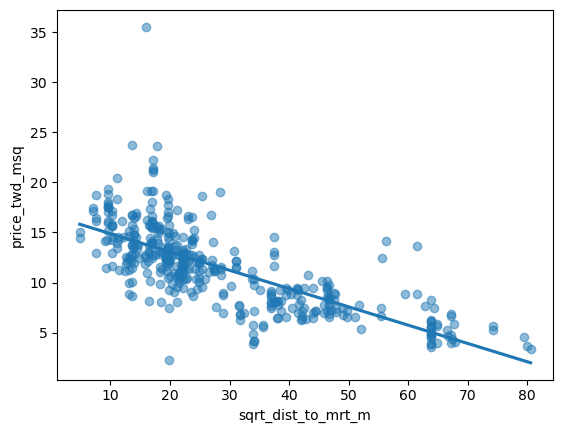

In [45]:
# Create sqrt_dist_to_mrt_m
taiwan_real_estate["sqrt_dist_to_mrt_m"] = np.sqrt(taiwan_real_estate["dist_to_mrt_m"])

# Plot using the transformed variable
sns.regplot(x="sqrt_dist_to_mrt_m",
            y="price_twd_msq",
            data=taiwan_real_estate,
            ci=None,
            scatter_kws={'alpha': 0.5})
plt.show()

Now, this is a different line compared to what was shown before. We can see that the points follow the line more closely than in the previous model.

Let's try creating a new linear model that uses the newly transformed `sqrt_dist_to_mrt` to predict `price_twd_msq`. We will also create a new exploratory data that includes our generated test predictions and plot them on the original scatterplot for comparison.

In [47]:
# Run a linear regression of price_twd_msq vs. square root of dist_to_mrt_m using taiwan_real_estate
mdl_price_vs_dist = ols("price_twd_msq ~ sqrt_dist_to_mrt_m", data=taiwan_real_estate).fit()

# Print the parameters
print(mdl_price_vs_dist.params)

Intercept             16.709799
sqrt_dist_to_mrt_m    -0.182843
dtype: float64


In [48]:
# Use the transformed explanatory data
explanatory_data3 = pd.DataFrame({"dist_to_mrt_m": np.arange(0, 81, 10) ** 2,
                                  "sqrt_dist_to_mrt_m": np.sqrt(np.arange(0, 81, 10) ** 2)})

# Use mdl_price_vs_dist to predict explanatory_data3
prediction_data3 = explanatory_data3.assign(
    price_twd_msq = mdl_price_vs_dist.predict(explanatory_data3)
)

# Print the prediction data
print(prediction_data3)

   dist_to_mrt_m  sqrt_dist_to_mrt_m  price_twd_msq
0              0                 0.0      16.709799
1            100                10.0      14.881370
2            400                20.0      13.052942
3            900                30.0      11.224513
4           1600                40.0       9.396085
5           2500                50.0       7.567656
6           3600                60.0       5.739227
7           4900                70.0       3.910799
8           6400                80.0       2.082370


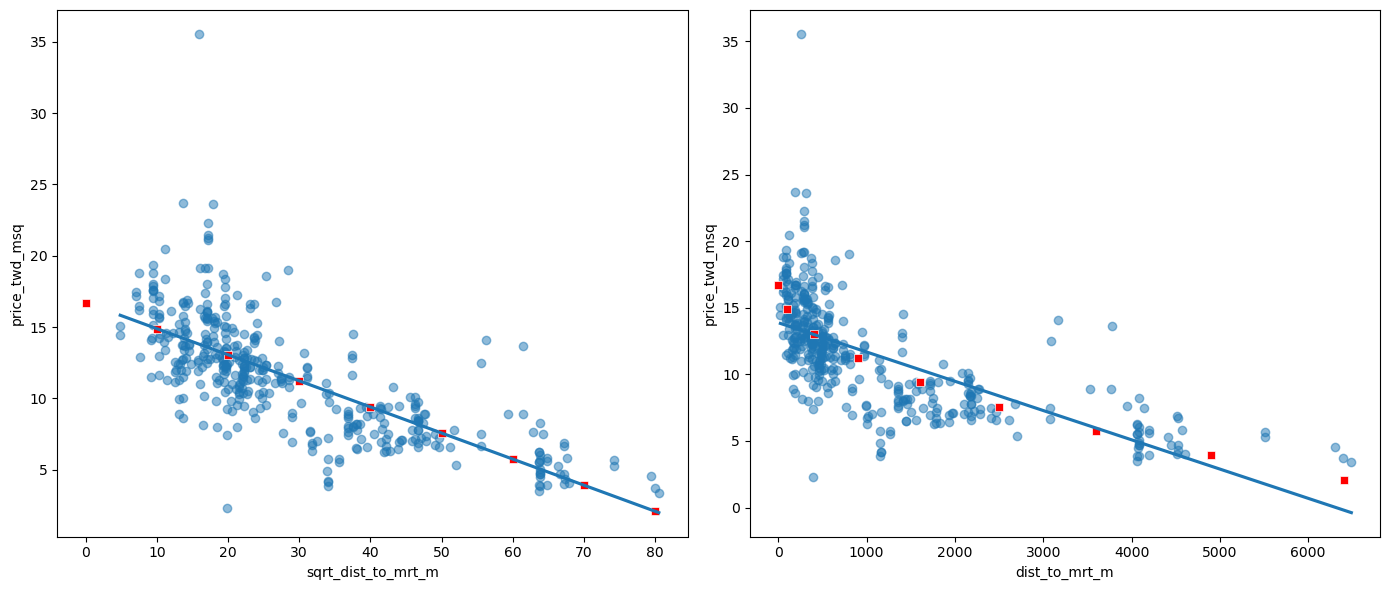

In [49]:
# Create a figure to compare transformed and untransformed dist_to_mrt_m vs. price_twd_msq
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# First plot: sqrt_dist_to_mrt_m vs price_twd_msq
sns.regplot(x="sqrt_dist_to_mrt_m",
            y="price_twd_msq",
            data=taiwan_real_estate,
            ci=None,
            scatter_kws={'alpha': 0.5},
            ax=ax[0])  # Specify the axis

# Add a layer of our prediction points
sns.scatterplot(x="sqrt_dist_to_mrt_m",
                y="price_twd_msq",
                data=prediction_data3,
                color="red",
                marker='s',
                ax=ax[0])

# Second plot: dist_to_mrt_m vs price_twd_msq
sns.regplot(x="dist_to_mrt_m",
            y="price_twd_msq",
            data=taiwan_real_estate,
            ci=None,
            scatter_kws={'alpha': 0.5},
            ax=ax[1])  # Specify the axis

# Add a layer of our prediction points
sns.scatterplot(x="dist_to_mrt_m",
                y="price_twd_msq",
                data=prediction_data3,
                color="red",
                marker='s',
                ax=ax[1])

# Adjust the layout
plt.tight_layout()

# Show the combined plots
plt.show()

Now we can have a clearier view that our original dataset has a non-linear relationship for our modle `dist_to_mrt_m` vs. `price_twd_msq`.

Summary:

1. **For prediction**, using `sqrt_dist_to_mrt_m` seems to improve the model, so it's fair to use it, and **we should include the transformed variable in our model**.
2. **For interpretation**, we can explain that **as the distance to the MRT station increases, its impact on price decreases more gradually**. (Our plot shows that being 100 meters from an MRT station has a more pronounced effect than being 1000 meters away.)

### One-Hot Encoding

Since our previous analysis showed that the lower the house age, the higher the price, we initially grouped the house age feature into intervals (e.g., 0 to 15 years, 15 to 30 years). 

To improve the accuracy of our linear regression model and to quantify the relationship between house age and price, we need to apply appropriate encoding methods. **This will allow us to represent the age feature in a way that captures its effect on price and enables better coefficient estimation in the later regression model.**

In [54]:
# Automatically create dummy variables (one-hot encoding)
df_dummies = pd.get_dummies(taiwan_real_estate,
                            columns=['house_age_years'],
                            drop_first=True)  # drop_first=True to avoid multicollinearity

# Display the resulting DataFrame with dummy variables
df_dummies

,dist_to_mrt_m,n_convenience,price_twd_msq,sqrt_dist_to_mrt_m,house_age_years_15 to 30,house_age_years_30 to 45
0,84.87882,10,11.467474,9.212970,False,True
1,306.59470,9,12.768533,17.509846,True,False
2,561.98450,5,14.311649,23.706212,False,False
3,561.98450,5,16.580938,23.706212,False,False
4,390.56840,5,13.040847,19.762803,False,False
...,...,...,...,...,...,...
409,4082.01500,0,4.659607,63.890649,False,False
410,90.45606,9,15.128593,9.510839,False,False
411,390.96960,7,12.284418,19.772951,True,False
412,104.81010,5,15.885023,10.237680,False,False


## Linear Regression: With Two Variables (number of convenience stores + sqrt distance to MRT station)

Now we will create another linear model called `mdl_price_vs_conv_sqrt_dist` and compare it with our previous model `mdl_price_vs_conv` to see which perfrom better.

In [57]:
# Create the model object
mdl_price_vs_conv_sqrt_dist = ols("price_twd_msq ~ n_convenience + sqrt_dist_to_mrt_m", data=taiwan_real_estate)

# Fit the model
mdl_price_vs_conv_sqrt_dist = mdl_price_vs_conv_sqrt_dist.fit()

# Print the parameters of the fitted model
print(mdl_price_vs_conv_sqrt_dist.params)

Intercept             15.103790
n_convenience          0.214221
sqrt_dist_to_mrt_m    -0.157300
dtype: float64


### Assess Model Fit

#### R-squared

In [60]:
print(mdl_price_vs_conv_sqrt_dist.summary())

                            OLS Regression Results                            
Dep. Variable:          price_twd_msq   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.544
Method:                 Least Squares   F-statistic:                     247.0
Date:                Sat, 07 Sep 2024   Prob (F-statistic):           3.60e-71
Time:                        20:04:22   Log-Likelihood:                -1009.4
No. Observations:                 414   AIC:                             2025.
Df Residuals:                     411   BIC:                             2037.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             15.1038      0

**The second model is clearly superior to the first! With a higher adjusted R-squared value (54.4%), it explains a significantly greater portion of the variance in price per square meter.**

By including both n_convenience and sqrt_dist_to_mrt_m as independent variables, the model offers a more comprehensive understanding of the factors influencing property prices. **It captures not only the positive impact of convenience stores but also the negative effect of distance from MRT stations**, providing a more nuanced and accurate depiction of the drivers of property values.

#### Residual Error

Residuals, which are the differences between observed and predicted values, are a valuable metric for understanding how much discrepancy exists between the actual data points and the values predicted by the model.

It is common practice to visualize residuals against fitted values to assess the assumptions of linearity and homoscedasticity (constant variance). Additionally, a Q-Q (Quantile-Quantile) plot is often used to check whether the residuals follow a normal distribution, which is an important assumption in linear regression models for reliable statistical inference

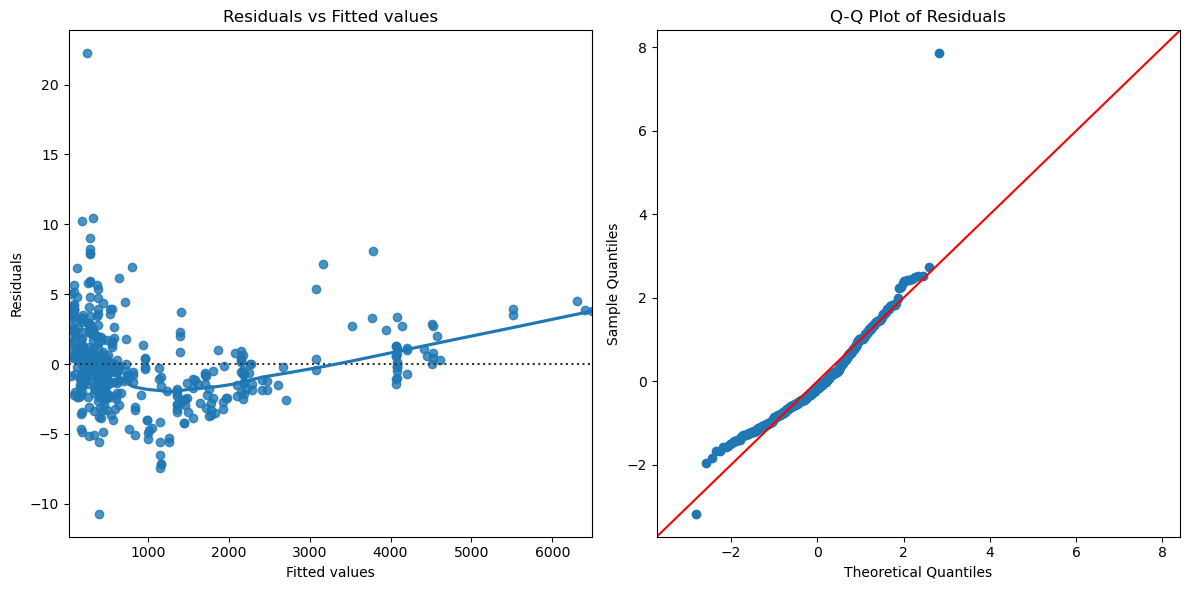

In [64]:
from statsmodels.graphics.gofplots import qqplot

# Create a 1x2 subplot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# First plot: Residuals vs. Fitted values
sns.residplot(x="dist_to_mrt_m", y="price_twd_msq", data=taiwan_real_estate, lowess=True, ax=axs[0])
axs[0].set_xlabel("Fitted values")
axs[0].set_ylabel("Residuals")
axs[0].set_title("Residuals vs Fitted values")

# Second plot: Q-Q plot of the residuals
qqplot(data=mdl_price_vs_conv.resid, fit=True, line="45", ax=axs[1])
axs[1].set_title("Q-Q Plot of Residuals")

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

Key Observations:

1. Residuals are randomly scattered around the horizontal axis (0 line), with no clear pattern. **This indicates that the model captures the underlying relationship well, and the variance of the residuals is constant (homoscedasticity).**

2. The Q-Q plot shows that the residuals generally follow a normal distribution, only a few points deviating from the line at the extremes, suggesting possible outliers or non-normality in the tails.

**Overall, our multiple linear regression model performs a mediocre job in predicting house prices, achieving an R-squared value of 54.6%. However, it would be inefficient and impractical to manually test each combination of features to find the optimal model.**

**To address this issue, we can explore ensemble methods, which combine the predictions of multiple models to improve performance, robustness, and accuracy. These methods, such as bagging, boosting, and stacking, can intelligently weigh features and models, providing a more powerful and efficient approach to optimizing the prediction of house prices.**

## Linear Regression with RandomForest and GradientBossting

To enhance your linear regression model using ensemble methods and evaluate its performance, we will implement techniques like Random Forests, Gradient Boosting Machines (GBM), and Stacking. These methods help automatically select important features and improve the model's predictive accuracy.

Here are the steps we will perform:

**1. Feature Selection Using Ensemble Methods**

Use ensemble methods like Random Forest and Gradient Boosting to identify the most influential features for predicting house prices.
After selecting the important features, refine our linear regression model by using only those features.

**2. Stacking to Combine Multiple Models**

Utilize Stacking to integrate the predictions from different models, such as Linear Regression, Random Forest, and Gradient Boosting, to create a more accurate final prediction. This will allows us to leverage the strengths of each model for better results.


### Train-Test Split

Before training the model, it is crucial to set aside a portion of the training data for evaluation. This ensures that we can later assess the model's performance on unseen data, providing a more reliable estimate of its generalization ability.

In [68]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import StackingRegressor

# Assuming 'Price' is the target variable
X = df_dummies.drop(columns=['price_twd_msq'])
y = df_dummies['price_twd_msq']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
X_train

,dist_to_mrt_m,n_convenience,sqrt_dist_to_mrt_m,house_age_years_15 to 30,house_age_years_30 to 45
192,57.58945,7,7.588771,False,True
234,2216.61200,4,47.080909,False,False
5,2175.03000,3,46.637217,False,False
45,488.81930,8,22.109258,False,True
245,639.61980,5,25.290706,False,False
...,...,...,...,...,...
71,640.73910,3,25.312825,False,True
106,189.51810,8,13.766557,True,False
270,252.58220,1,15.892835,False,False
348,259.66070,6,16.113991,False,False


In [70]:
X_test

,dist_to_mrt_m,n_convenience,sqrt_dist_to_mrt_m,house_age_years_15 to 30,house_age_years_30 to 45
358,193.5845,6,13.913465,False,False
350,492.2313,5,22.186286,False,False
373,274.0144,1,16.553380,False,False
399,170.1289,1,13.043347,False,False
369,2185.1280,3,46.745353,True,False
...,...,...,...,...,...
31,769.4034,7,27.738122,True,False
283,1978.6710,2,44.482255,False,True
157,815.9314,4,28.564513,True,False
203,289.3248,5,17.009550,True,False


### Model Training

Random Forests work by constructing multiple decision trees (estimators) and averaging their results. In our case, 20 trees (n_estimators=20) are chosen. This number is sufficient to capture a diverse range of patterns in the data without making the model overly complex or computationally expensive.

As for Gradient Boosting, it iteratively improves predictions by focusing on the errors made by the previous model. Like Random Forest, using 20 trees strikes a balance between model performance and computational cost, making it a reasonable choice for our dataset size.

In [131]:
# Define the models
random_forest = RandomForestRegressor(n_estimators=20, random_state=42)
gradient_boosting = GradientBoostingRegressor(n_estimators=20, random_state=42)
linear_regression = LinearRegression()

# Stacking: Combine multiple models and select the most influential features, including linear regression
estimators = [
    ('rf', random_forest),
    ('gb', gradient_boosting)
]
stacked_model = StackingRegressor(estimators=estimators, final_estimator=linear_regression)

# Train the models
stacked_model.fit(X_train, y_train)

# Predict house prices
y_pred = stacked_model.predict(X_test)
y_pred

array([15.0040204 , 12.48573525, 14.41137092, 12.04351835,  8.04555715,
       11.0840349 , 14.71475349, 14.71475349,  6.42473086, 16.65358058,
        7.99479792,  8.76403004,  7.87651278,  6.03501548, 12.26205107,
        8.1668748 , 12.32500096, 16.7084266 ,  7.91369272, 12.28331445,
        6.01701057,  7.70467648, 13.6382108 , 17.98502969,  5.74661477,
       12.8962685 ,  5.50891102, 14.41137092, 13.64971645, 11.35827906,
        4.93782363,  7.91187585,  8.51116829,  8.49142045, 15.37652243,
       11.66740514, 16.65358058,  6.01607096, 13.21827892, 12.83968096,
       11.91145838, 12.55615881, 14.73553012, 11.77102754, 12.48573525,
       14.64447845, 11.4377719 ,  7.90105042, 15.842633  , 14.84432566,
       15.0040204 , 15.18114948, 12.18101152,  8.1724388 , 11.40867743,
        6.01607096, 11.51921707,  8.6057574 ,  8.04555715, 14.71475349,
        8.79031005,  8.15537509,  6.01607096,  5.15077495,  4.82090902,
        7.70467648,  8.67504639, 11.64298592, 12.13193625,  8.67

### Evaluate Model Performance

In [127]:
# Evaluate the model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Feature importance from Random Forest
random_forest.fit(X_train, y_train)
importances = random_forest.feature_importances_
important_features = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
print("Feature Importances:\n", important_features)

Mean Absolute Error: 1.333573146327217
Mean Squared Error: 3.5656646763847624
R-squared: 0.7678355763288168
Feature Importances:
 dist_to_mrt_m               0.503313
sqrt_dist_to_mrt_m          0.384069
n_convenience               0.061377
house_age_years_30 to 45    0.032037
house_age_years_15 to 30    0.019205
dtype: float64


#### Key Improvements:

**R² Improvement:** The stacked model shows a significant improvement in the R-squared value (from 0.546 to 0.767), meaning the Random Forest explains 76.7% of the variance compared to 54.6% in the OLS model. This suggests that using esemble model help us capture more of the complexity in the data.

**Non-linearity:** By incoprating boosting method can handle non-linear relationships better than OLS, which is likely why it performs better here. The feature importance breakdown also suggests that it’s not only relying on a few variables (as OLS does) but considers a broader range of factors.

**Error Reduction:** The Mean Absolute Error and Mean Squared Error are specific indicators that the predictions from the Random Forest model are closer to the actual values than those of a linear regression.